In [1]:
import torch
print(torch.__version__)

2.9.0


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

In [3]:
def create_model():
    net = nn.Sequential(
        nn.Linear(1, 32),
        nn.Tanh(),
        nn.Linear(32, 32),
        nn.Tanh(),
        nn.Linear(32, 32),
        nn.Tanh(),
        nn.Linear(32, 1)
    )
    return net

In [4]:
def double_derivative(model, x):
    x.requires_grad = True
    u = model(x)
    du_dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u_dx2 = torch.autograd.grad(du_dx, x, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0]
    return d2u_dx2

In [5]:
def compute_loss(model, f, x_interior, x_boundary, u_target, lambda_bc):
    d2u_dx2 = double_derivative(model, x_interior)
    res = -d2u_dx2 - f(x_interior)
    L_pde = torch.mean(res**2)
    u_boundary = model(x_boundary)
    L_bc = torch.mean((u_boundary - u_target)**2)
    L_total = L_pde + lambda_bc * L_bc
    return L_total, L_pde.item(), L_bc.item()

In [6]:
def train(model, f, u_left, u_right, epochs=8000, n_collocation=1000, lambda_bc=100, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9)
    x_boundary = torch.tensor([[0.0], [1.0]], dtype=torch.float32)
    history = {'total_loss': [], 'pde_loss': [], 'bc_loss': []}
    u_target = torch.tensor([[u_left], [u_right]], dtype=torch.float32)

    t_start = time.perf_counter()
    for epoch in range(epochs):
        x_interior = torch.rand((n_collocation, 1), dtype=torch.float32)
        x_interior.requires_grad = True
        
        loss, pde_loss, bc_loss = compute_loss(model, f, x_interior, x_boundary, u_target, lambda_bc)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        history['total_loss'].append(loss.item())
        history['pde_loss'].append(pde_loss)
        history['bc_loss'].append(bc_loss)
        
        if epoch % 1000 == 0:
            print(f"Epoch {epoch}, Total Loss: {loss.item():.6f}, PDE Loss: {pde_loss:.6f}, BC Loss: {bc_loss:.6f}")
    t_end = time.perf_counter()
    elapsed = t_end - t_start
            
    return history, elapsed

In [7]:
def evaluate(model, exact_solution):
    x_test = torch.linspace(0, 1, 100).unsqueeze(1)
    with torch.no_grad():
        u_pred = model(x_test).numpy()
    
    u_exact = exact_solution(x_test).numpy()
    error = np.abs(u_pred - u_exact)

    metrics = {'max_err': np.max(error), 'mean_err': np.mean(error), 'rel_l2': np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)}
    
    print(f"Max Absolute Error: {np.max(error):.6f}")
    print(f"Mean Absolute Error: {np.mean(error):.6f}")
    print(f"Relative L2 Error: {np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact):.6f}")

    return x_test.numpy(), u_pred, u_exact, error, metrics

In [8]:
def plot_results(x_test, u_pred, u_exact, error, history):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    axs[0].plot(x_test, u_exact, label='Exact Solution', color='blue')
    axs[0].plot(x_test, u_pred, label='PINN Prediction', color='red', linestyle='dashed')
    axs[0].set_title('Exact vs PINN Solution')
    axs[0].set_xlabel('x')
    axs[0].legend()

    axs[1].plot(x_test, error, label='Absolute Error', color='green')
    axs[1].set_title('Absolute Error')
    axs[1].set_xlabel('x')
    axs[1].legend()

    axs[2].semilogy(history['total_loss'], label='Total Loss', color='purple')
    axs[2].semilogy(history['pde_loss'], label='PDE Loss', color='orange')
    axs[2].semilogy(history['bc_loss'], label='Boundary Loss', color='cyan')
    axs[2].set_title('Training Loss History')
    axs[2].set_xlabel('Epoch')
    axs[2].legend()

    plt.tight_layout()
    plt.show()

In [9]:
timing_records = []

Epoch 0, Total Loss: 47.227306, PDE Loss: 47.002640, BC Loss: 0.002247
Epoch 1000, Total Loss: 0.002616, PDE Loss: 0.001263, BC Loss: 0.000014
Epoch 2000, Total Loss: 0.001277, PDE Loss: 0.000706, BC Loss: 0.000006
Epoch 3000, Total Loss: 0.000341, PDE Loss: 0.000337, BC Loss: 0.000000
Epoch 4000, Total Loss: 0.002239, PDE Loss: 0.000300, BC Loss: 0.000019
Epoch 5000, Total Loss: 0.001407, PDE Loss: 0.000228, BC Loss: 0.000012
Epoch 6000, Total Loss: 0.000169, PDE Loss: 0.000141, BC Loss: 0.000000
Epoch 7000, Total Loss: 0.000188, PDE Loss: 0.000112, BC Loss: 0.000001
Training time: 13.34s
Max Absolute Error: 0.004395
Mean Absolute Error: 0.004104
Relative L2 Error: 0.005844


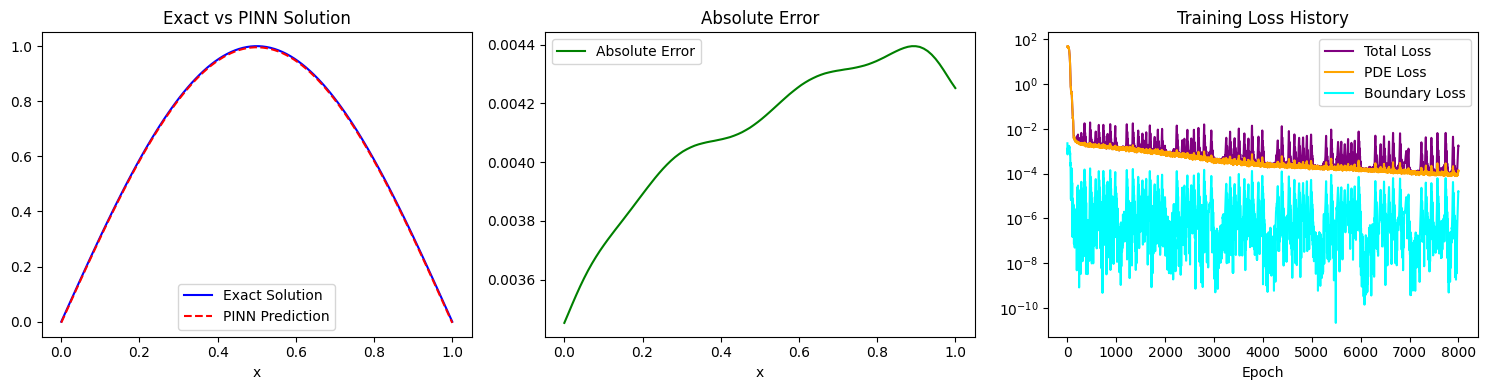

In [10]:
# Problem 1: Standard Sine Wave (Your Original)
# PDE: -u'' = pi^2 * sin(pi*x)
# Exact: u(x) = sin(pi*x)

f = lambda x: (torch.pi**2) * torch.sin(torch.pi * x)
u_left, u_right = 0.0, 0.0
exact = lambda x: torch.sin(torch.pi * x)
problem_name = "Problem 1: Sine Wave"

net = create_model()

history, elapsed = train(net, f, u_left, u_right, epochs=8000, n_collocation=1000, lambda_bc=100, lr=0.001)
print(f"Training time: {elapsed:.2f}s")
x_test, u_pred, u_ref, error, metrics = evaluate(net, exact)
timing_records.append({'problem': problem_name, 'epochs': 8000, 'n_collocation': 1000, 'train_time_s': elapsed, **metrics})

plot_results(x_test, u_pred, u_ref, error, history)

Epoch 0, Total Loss: 4.589580, PDE Loss: 4.124119, BC Loss: 0.004655
Epoch 1000, Total Loss: 0.000476, PDE Loss: 0.000469, BC Loss: 0.000000
Epoch 2000, Total Loss: 0.000101, PDE Loss: 0.000101, BC Loss: 0.000000
Epoch 3000, Total Loss: 0.000025, PDE Loss: 0.000025, BC Loss: 0.000000
Epoch 4000, Total Loss: 0.000015, PDE Loss: 0.000015, BC Loss: 0.000000
Epoch 5000, Total Loss: 0.000021, PDE Loss: 0.000014, BC Loss: 0.000000
Epoch 6000, Total Loss: 0.000015, PDE Loss: 0.000015, BC Loss: 0.000000
Epoch 7000, Total Loss: 0.000031, PDE Loss: 0.000014, BC Loss: 0.000000
Training time: 13.24s
Max Absolute Error: 0.000025
Mean Absolute Error: 0.000011
Relative L2 Error: 0.000072


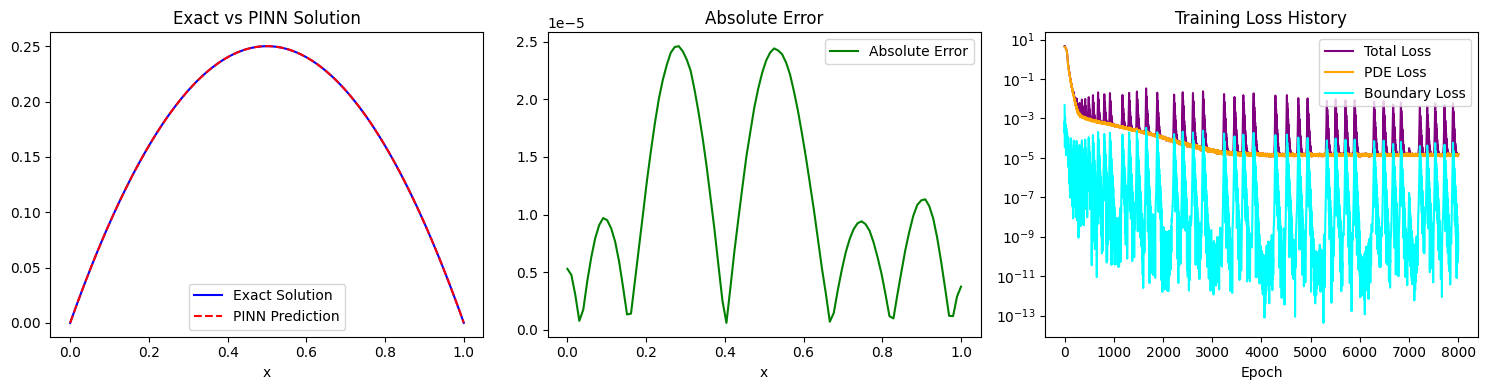

In [11]:
# Problem 2: Simple Polynomial
# PDE: -u'' = 2
# Exact: u(x) = x * (1 - x)  [or x - x^2]

f = lambda x: 2.0 * torch.ones_like(x)
u_left, u_right = 0.0, 0.0
exact = lambda x: x * (1 - x)
problem_name = "Problem 2: Polynomial"

net = create_model()

history, elapsed = train(net, f, u_left, u_right, epochs=8000, n_collocation=1000, lambda_bc=100, lr=0.001)
print(f"Training time: {elapsed:.2f}s")
x_test, u_pred, u_ref, error, metrics = evaluate(net, exact)
timing_records.append({'problem': problem_name, 'epochs': 8000, 'n_collocation': 1000, 'train_time_s': elapsed, **metrics})

plot_results(x_test, u_pred, u_ref, error, history)

Epoch 0, Total Loss: 767.011902, PDE Loss: 765.456482, BC Loss: 0.015554
Epoch 1000, Total Loss: 0.014588, PDE Loss: 0.014461, BC Loss: 0.000001
Epoch 2000, Total Loss: 0.006199, PDE Loss: 0.005981, BC Loss: 0.000002
Epoch 3000, Total Loss: 0.002927, PDE Loss: 0.002725, BC Loss: 0.000002
Epoch 4000, Total Loss: 0.002152, PDE Loss: 0.001782, BC Loss: 0.000004
Epoch 5000, Total Loss: 0.001812, PDE Loss: 0.001012, BC Loss: 0.000008
Epoch 6000, Total Loss: 0.000490, PDE Loss: 0.000461, BC Loss: 0.000000
Epoch 7000, Total Loss: 0.000185, PDE Loss: 0.000181, BC Loss: 0.000000
Training time: 13.90s
Max Absolute Error: 0.004260
Mean Absolute Error: 0.001370
Relative L2 Error: 0.002613


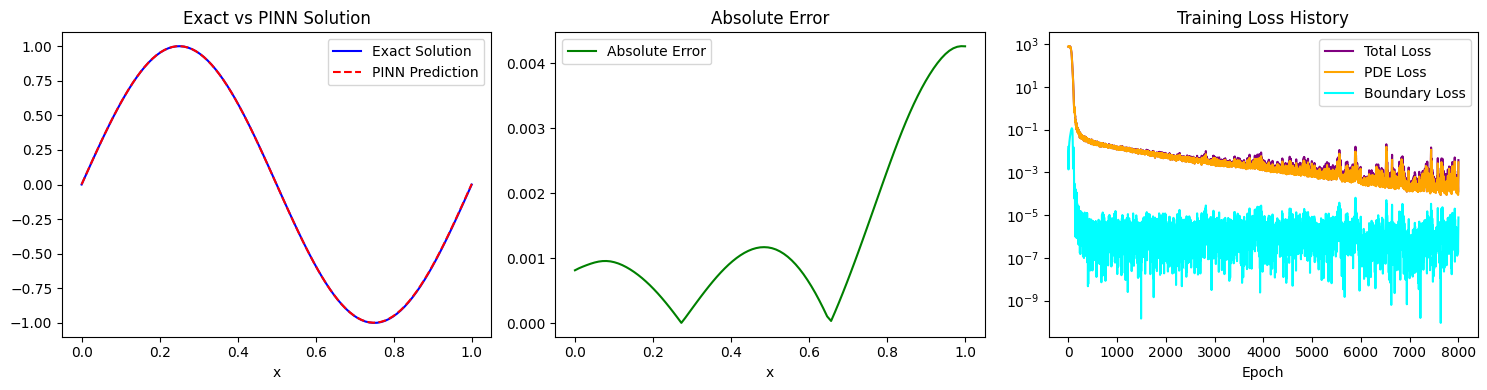

In [12]:
# Problem 3: Higher Frequency Sine (Harder for PINNs)
# PDE: -u'' = 4*pi^2 * sin(2*pi*x)
# Exact: u(x) = sin(2*pi*x)

f = lambda x: (4 * torch.pi**2) * torch.sin(2 * torch.pi * x)
u_left, u_right = 0.0, 0.0
exact = lambda x: torch.sin(2 * torch.pi * x)
problem_name = "Problem 3: High-Freq Sine"

net = create_model()

history, elapsed = train(net, f, u_left, u_right, epochs=8000, n_collocation=1000, lambda_bc=100, lr=0.001)
print(f"Training time: {elapsed:.2f}s")
x_test, u_pred, u_ref, error, metrics = evaluate(net, exact)
timing_records.append({'problem': problem_name, 'epochs': 8000, 'n_collocation': 1000, 'train_time_s': elapsed, **metrics})

plot_results(x_test, u_pred, u_ref, error, history)

Epoch 0, Total Loss: 425.459106, PDE Loss: 3.052074, BC Loss: 4.224071
Epoch 1000, Total Loss: 0.007450, PDE Loss: 0.007445, BC Loss: 0.000000
Epoch 2000, Total Loss: 0.003225, PDE Loss: 0.003224, BC Loss: 0.000000
Epoch 3000, Total Loss: 0.002044, PDE Loss: 0.002043, BC Loss: 0.000000
Epoch 4000, Total Loss: 0.001086, PDE Loss: 0.001085, BC Loss: 0.000000
Epoch 5000, Total Loss: 0.000535, PDE Loss: 0.000535, BC Loss: 0.000000
Epoch 6000, Total Loss: 0.000198, PDE Loss: 0.000197, BC Loss: 0.000000
Epoch 7000, Total Loss: 0.000092, PDE Loss: 0.000055, BC Loss: 0.000000
Training time: 13.28s
Max Absolute Error: 0.000458
Mean Absolute Error: 0.000397
Relative L2 Error: 0.000223


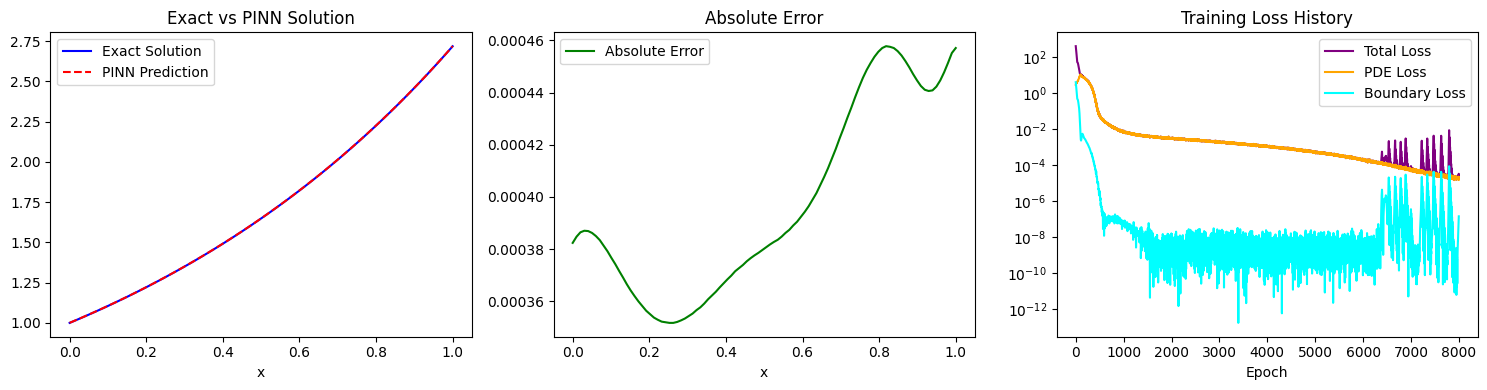

In [13]:
# Problem 4: Non-Zero Boundary Conditions
# PDE: -u'' = -e^x
# Exact: u(x) = e^x
# Boundary: u(0) = 1, u(1) = e

f = lambda x: -torch.exp(x)
u_left = 1.0 
u_right = torch.exp(torch.tensor(1.0)).item() # approx 2.718
exact = lambda x: torch.exp(x)
problem_name = "Problem 4: Exponential (Non-zero BCs)"

net = create_model()

history, elapsed = train(net, f, u_left, u_right, epochs=8000, n_collocation=1000, lambda_bc=100, lr=0.001)
print(f"Training time: {elapsed:.2f}s")
x_test, u_pred, u_ref, error, metrics = evaluate(net, exact)
timing_records.append({'problem': problem_name, 'epochs': 8000, 'n_collocation': 1000, 'train_time_s': elapsed, **metrics})

plot_results(x_test, u_pred, u_ref, error, history)